<a href="https://colab.research.google.com/github/gabyx7677/proyectos_generales/blob/main/Proyecto_Sprint_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Se importan todas las librerías que a lo largo del proyecto de usaran

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualización de dfs
# Meramente estético y para organización de la info


def mostrar_dfs(dfs, wide_titles=None):
    """
    Muestra múltiples DataFrames con estilo HTML adaptado para modo oscuro.

    Parámetros:
    - dfs: lista de tuplas (titulo, df, head_n, [opcional] is_wide)
      ejemplo: [("Título 1", df1, 10), ("Título 2", df2, None, True)]
    - wide_titles: lista de títulos que deben mostrarse a ancho completo
    """
    if wide_titles is None:
        wide_titles = []

    html_blocks = []

    for item in dfs:
        if len(item) == 4:
            title, df, head_n, is_wide = item
        else:
            title, df, head_n = item
            is_wide = title in wide_titles

        if head_n is not None:
            df = df.head(head_n)

        table_html = df.to_html(index=True)

        css_class = "df-box wide" if is_wide else "df-box"

        block = f"""
        <div class="{css_class}">
            <h3>{title}</h3>
            {table_html}
        </div>
        """
        html_blocks.append(block)

    full_html = f"""
    <style>
        table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
            background-color: #1e1e1e;
            color: #f0f0f0;
        }}
        th, td {{
            border: 1px solid #444;
            padding: 6px;
            text-align: center;
            max-width: 200px;
            white-space: nowrap;
            text-overflow: ellipsis;
            overflow: hidden;
        }}
        th {{
            background-color: #2a2a2a;
            font-weight: bold;
            color: #ffffff;
        }}
        table th:first-child,
        table td:first-child {{
            width: 10%;

        }}
        h3 {{
            margin-top: 0;
            font-size: 16px;
            color: #f2f2f2;
        }}
        .df-container {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(320px, 1fr));
            gap: 15px;
            margin-bottom: 30px;
        }}
        .df-box {{
            border: 1px solid #555;
            border-radius: 6px;
            padding: 10px;
            background-color: #2b2b2b;
            overflow-x: auto;
            box-shadow: 1px 1px 4px rgba(0,0,0,0.4);
        }}
        .df-box.wide {{
            grid-column: 1 / -1;
        }}
    </style>
    <div class="df-container">
        {''.join(html_blocks)}
    </div>
    """


    display(HTML(full_html))






<div style="background-color: #FFFACD; padding: 10px; border-radius: 5px;">
  <strong></strong>

## Paso 4. Análisis exploratorio de datos (Python)
Inicialmente se importaron tres DataFrames principales desde archivos CSV:

`companies_and_trips`: contiene información sobre los nombres de las compañías de taxis y el número de viajes que realizaron los días 15 y 16 de noviembre de 2017.

`neighborhoods_dropoff`: muestra los barrios de Chicago donde finalizan los viajes y el promedio de viajes por barrio durante noviembre de 2017.

`trip_info`: registra viajes realizados los sábados desde el barrio Loop hacia el Aeropuerto Internacional O'Hare. Incluye la hora de inicio (start_ts), la duración del viaje (duration_seconds) y las condiciones climáticas (weather_conditions).

Los datos fueron enriquecidos con los siguientes indicadores:

`pct_total_market_share`: porcentaje del total de viajes realizados por cada empresa, con respecto al total general.

`pct_total_as_destiny`: porcentaje de viajes que terminan en cada barrio respecto al total de destinos.

Además, se formateó el campo de fecha en `trip_info` como tipo datetime y se ordenaron los registros cronológicamente.

Esta visualización permite tener un panorama general de los datos, facilitando el análisis posterior y la validación de su consistencia.


</div>

In [3]:
# Se importan los csv y se obtienen los dataframes correspondientes para su análisis

companies_and_trips = pd.read_csv('/content/moved_project_sql_result_01.csv')
neighborhoods_dropoff = pd.read_csv('/content/moved_project_sql_result_04.csv')
trip_info = pd.read_csv('/content/moved_project_sql_result_07.csv')

# Df 'trip_info' Organizados por fecha ascendente y con formato de fecha
trip_info['start_ts'] = pd.to_datetime(trip_info['start_ts'])
trip_info.sort_values(by='start_ts', ascending=True, inplace=True)


# Se enriquecen los datos con el fin de hacer un análisis por porcentaje de participación en el mercado
# Se calcula el porcentaje del total de viajes por compañía

companies_and_trips['pct_total_market_share'] = (
    companies_and_trips['trips_amount'] / companies_and_trips['trips_amount'].sum()
) * 100


# Se calcula el porcentaje del total de viajes por barrio de destino

neighborhoods_dropoff['pct_total_as_destiny'] = (
   neighborhoods_dropoff['average_trips'] / neighborhoods_dropoff['average_trips'].sum()
) * 100

In [4]:
mostrar_dfs([('Describe df info compañías', companies_and_trips.describe(), 10),
             ('Describe df info barrios destino', neighborhoods_dropoff.describe(), 30),
             ('Describe df info de viajes', trip_info.describe(), 30)
             ])

,trips_amount,pct_total_market_share
count,64.000000,64.000000
mean,2145.484375,1.562500
std,3812.310186,2.776406
min,2.000000,0.001457
25%,20.750000,0.015112
50%,178.500000,0.129997
75%,2106.500000,1.534109
max,19558.000000,14.243578
,average_trips,pct_total_as_destiny
count,94.000000,94.000000


In [5]:
# Los df no presentan valores nulos y los nombres de las columnas estan en formato snake_case, se puede trabajar con ellos

mostrar_dfs([('Valores nulos en df info compañías', companies_and_trips.isna().sum().reset_index(), 10),
             ('Valores nulos en df info barrios destino', neighborhoods_dropoff.isna().sum().reset_index(), 10),
             ('Valores nulos en df info de viajes', trip_info.isna().sum().reset_index(), 10)
             ])

,index,0
0,company_name,0
1,trips_amount,0
2,pct_total_market_share,0
,index,0
0,dropoff_location_name,0
1,average_trips,0
2,pct_total_as_destiny,0
,index,0
0,start_ts,0
1,weather_conditions,0


In [6]:
# El df 'companies_and_trips' contiene la info del nombre de la compañia, el numéro de viajes realizados por esta y el porcentaje de participación en el mercado
# El df 'neighborhoods_dropoff' contiene el nombre del barrio, el promedio de vijes que finalizan en ese barrio y el porcentaje como destino
# El df 'trip_info' contiene info sobre la hora de comienzo, las condiciones ambientales y la duración de los viajes entre el barrio Loop y el aeropuerto

mostrar_dfs([('Info compañías', companies_and_trips, 10),
             ('Info barrios destino', neighborhoods_dropoff, 10),
             ('Info de viajes', trip_info, 10)
             ])

,company_name,trips_amount,pct_total_market_share
0,Flash Cab,19558,14.243578
1,Taxi Affiliation Services,11422,8.318343
2,Medallion Leasin,10367,7.550014
3,Yellow Cab,9888,7.201171
4,Taxi Affiliation Service Yellow,9299,6.772218
5,Chicago Carriage Cab Corp,9181,6.686282
6,City Service,8448,6.152457
7,Sun Taxi,7701,5.608436
8,Star North Management LLC,7455,5.429281
9,Blue Ribbon Taxi Association Inc.,5953,4.335414


In [7]:
# NO ES POSIBLE HACER HISTOGRAMAS DE FRECUENCIA PORQUE NO TENEMOS EL TIEMPO, FECHA, HORA DONDE SE HIZO EL VIAJE, POR ENDE NO SE PUEDE MEDIR

# SOLO SE TIENE LA INFO TEMPORAR DE LOS VIAJES DESDE EL BARRIO LOOP HASTA EL AEROPUERTO, SE PODRIAN HACER HISTOGRAMAS AHI

,dropoff_location_name,average_trips,pct_total_as_destiny
0,Loop,10727.466667,19.021798
1,River North,9523.666667,16.887236
2,Streeterville,6664.666667,11.817696
3,West Loop,5163.666667,9.156143
4,O'Hare,2546.900000,4.516128
5,Lake View,2420.966667,4.292825
6,Grant Park,2068.533333,3.667895
7,Museum Campus,1510.000000,2.677511
8,Gold Coast,1364.233333,2.419040
9,Sheffield & DePaul,1259.766667,2.233801


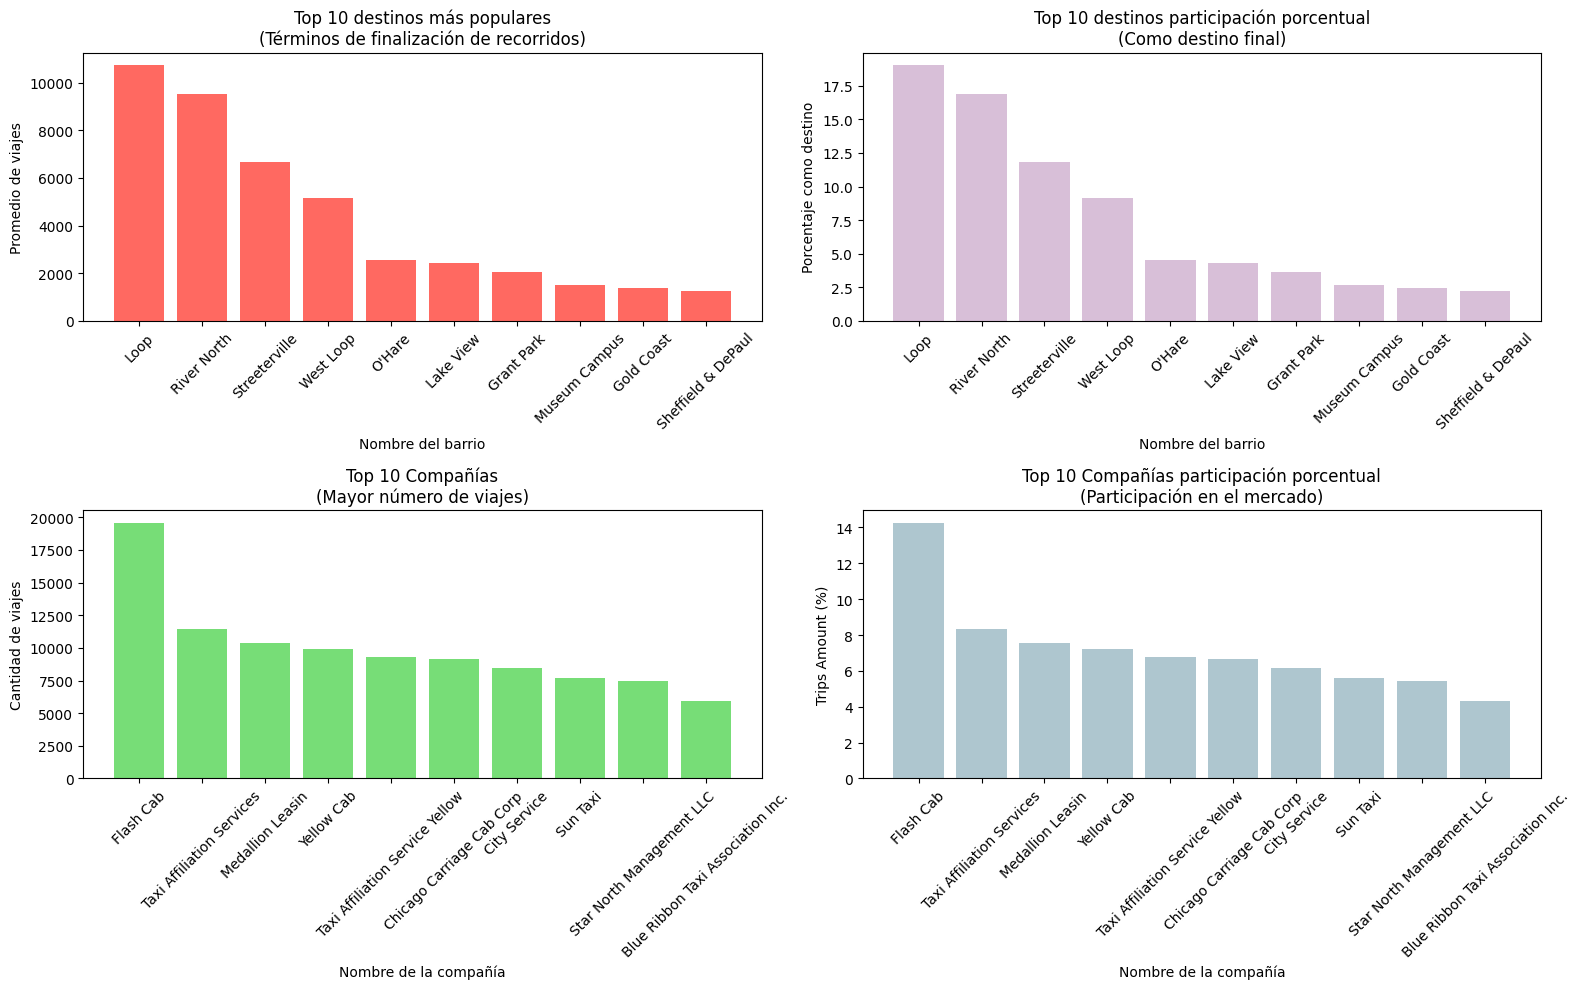

In [8]:
# Se visualizan los 10 barrios más populares en términos de finalización de recorridos
# Junto con las 10 compañías más populares

top_neighborhoods = neighborhoods_dropoff.sort_values(by='average_trips', ascending=False)
top_companies = companies_and_trips.sort_values(by='trips_amount', ascending=False)


mostrar_dfs([('Top 10 barrios destino', top_neighborhoods, 10),
             ('Top 10 compañías', top_companies, 10)
             ])


# Se definen los parámetros de cada subplot
graficos = [
    {
        'df': top_neighborhoods.head(10),
        'x': 'dropoff_location_name',
        'y': 'average_trips',
        'color': '#FF6961',
        'title': 'Top 10 destinos más populares\n(Términos de finalización de recorridos)',
        'xlabel': 'Nombre del barrio',
        'ylabel': 'Promedio de viajes'
    },
    {
        'df': top_neighborhoods.head(10),
        'x': 'dropoff_location_name',
        'y': 'pct_total_as_destiny',
        'color': '#D8BFD8',
        'title': 'Top 10 destinos participación porcentual\n(Como destino final)',
        'xlabel': 'Nombre del barrio',
        'ylabel': 'Porcentaje como destino'
    },
    {
        'df': top_companies.head(10),
        'x': 'company_name',
        'y': 'trips_amount',
        'color': '#77DD77',
        'title': 'Top 10 Compañías\n(Mayor número de viajes)',
        'xlabel': 'Nombre de la compañía',
        'ylabel': 'Cantidad de viajes'
    },
    {
        'df': top_companies.head(10),
        'x': 'company_name',
        'y': 'pct_total_market_share',
        'color': '#AEC6CF',
        'title': 'Top 10 Compañías participación porcentual\n(Participación en el mercado)',
        'xlabel': 'Nombre de la compañía',
        'ylabel': 'Trips Amount (%)'
    }
]

# Se crea el lienzo de 2x2
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()  # Aplana el array 2x2 para poder iterar

# Se recorre la lista de gráficos y se plotea cada uno
for ax, params in zip(axs, graficos):
    ax.bar(params['df'][params['x']], params['df'][params['y']], color=params['color'])
    ax.set_title(params['title'])
    ax.set_xlabel(params['xlabel'])
    ax.set_ylabel(params['ylabel'])
    ax.tick_params(axis='x', rotation=45)

# Se ajusta el layout para evitar solapamientos
plt.subplots_adjust(hspace=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


<div style="background-color: #cyan; padding: 10px; border-radius: 5px;">
  <strong></strong>

## Conclusiones del análisis exploratorio de compañías y destinos
En el análisis estático de los datos de viajes compartidos en Chicago se identifican patrones de concentración tanto en las compañías que prestan el servicio como en los destinos más frecuentes:

- Las 10 principales compañías de taxis concentran la mayor parte del mercado, destacándose Flash Cab con más del 14% del total de viajes, seguida por otras como Taxi Affiliation Services, Medallion Leasing y Yellow Cab. Esta distribución revela una clara concentración en pocas empresas líderes dentro del sector.

- Por otro lado, los barrios más frecuentemente elegidos como destino también muestran una distribución desigual. El barrio Loop lidera con un promedio de viajes significativamente superior, representando más del 19% del total de viajes, seguido por River North y Streeterville. Los 10 barrios principales representan una fracción sustancial de todos los destinos, lo que permite detectar zonas clave de alta demanda.

En conjunto, estos datos evidencian la existencia de un efecto de Pareto en ambas dimensiones: un número reducido de compañías y barrios concentra la mayoría de los viajes, lo que puede ser útil para estrategias operativas, distribución de flota y análisis de mercado.

</div>


<div style="background-color: #FFFACD; padding: 10px; border-radius: 5px;">
  <strong></strong>

## Paso 5. Prueba de hipótesis (Python)

el resultado de la última consulta. Contiene datos sobre viajes desde el Loop hasta el Aeropuerto Internacional O'Hare. Recuerda, estos son los valores de campo de la tabla:

- `start_ts`: fecha y hora de la recogida
- `weather_conditions`: condiciones climáticas en el momento en el que comenzó el viaje
- `duration_seconds`: duración del viaje en segundos
Prueba la hipótesis:

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Decide por tu cuenta dónde establecer el nivel de significación (alfa).

Explica:

cómo planteaste las hipótesis nula y alternativa
qué criterio usaste para probar las hipótesis y por qué

</div>

In [9]:
mostrar_dfs([('Info de viajes', trip_info, 10)])

,start_ts,weather_conditions,duration_seconds
893,2017-11-04 00:00:00,Good,1560.0
552,2017-11-04 01:00:00,Good,0.0
267,2017-11-04 02:00:00,Good,2956.0
741,2017-11-04 04:00:00,Good,1595.0
88,2017-11-04 04:00:00,Good,1333.0
791,2017-11-04 04:00:00,Good,1260.0
565,2017-11-04 04:00:00,Good,1440.0
938,2017-11-04 04:00:00,Good,1341.0
541,2017-11-04 05:00:00,Good,1200.0
357,2017-11-04 05:00:00,Good,1320.0


Valor p: 0.0000
Se rechaza la hipótesis nula: hay evidencia de que la duración promedio cambia los sábados lluviosos.



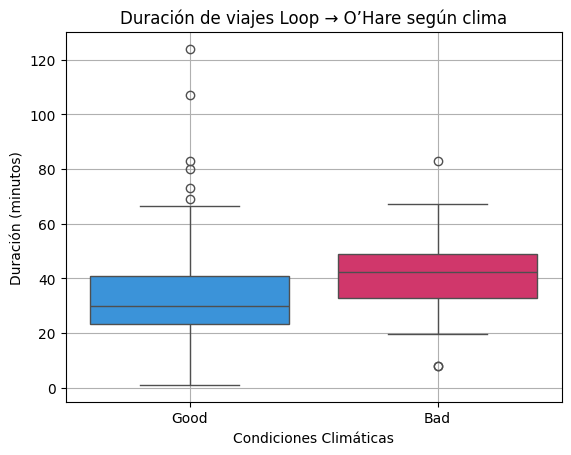

In [10]:
# Se importan las librerías necesarias
import pandas as pd
from scipy.stats import ttest_ind

# Se eliminan los registros con duración igual a cero o nula (datos inválidos)
trip_info = trip_info[trip_info['duration_seconds'] > 0]

# Se convierte la duración a minutos para facilitar la interpretación
trip_info['duration_min'] = trip_info['duration_seconds'] / 60

# Se separan los datos en dos grupos: viajes con clima 'Bad' (lluvioso) y 'Good' (seco)
rainy = trip_info[trip_info['weather_conditions'] == 'Bad']['duration_min']
dry = trip_info[trip_info['weather_conditions'] == 'Good']['duration_min']

# Se define el nivel de significancia
alpha = 0.05

# Se realiza la prueba t de Student para muestras independientes (varianzas no iguales)
stat, p_value = ttest_ind(rainy, dry, equal_var=False)

# Se muestran los resultados
print(f'Valor p: {p_value:.4f}')
if p_value < alpha:
    print('Se rechaza la hipótesis nula: hay evidencia de que la duración promedio cambia los sábados lluviosos.')
else:
    print('No se puede rechazar la hipótesis nula: no hay evidencia suficiente para afirmar un cambio en la duración promedio.')
print()

# Boxplot comparando la duración de viajes entre climas
sns.boxplot(data=trip_info, x='weather_conditions', y='duration_min', palette=['#2196F3', '#E91E63'])
plt.title('Duración de viajes Loop → O’Hare según clima')
plt.xlabel('Condiciones Climáticas')
plt.ylabel('Duración (minutos)')
plt.grid(True)
plt.show()

<div style="background-color: #cyan; padding: 10px; border-radius: 5px;">
  <strong></strong>

# Resultados

Se realizó una prueba de hipótesis para determinar si las condiciones climáticas (específicamente la lluvia) afectan la duración promedio de los viajes entre el barrio Loop y el Aeropuerto Internacional O’Hare durante los días sábado.

Formulación de hipótesis:
- Hipótesis nula (H₀): la duración promedio de los viajes es igual en sábados lluviosos y no lluviosos.

- Hipótesis alternativa (H₁): la duración promedio de los viajes cambia en sábados lluviosos.

Esta formulación implica una prueba bilateral (dos colas), ya que se evalúa si hay cualquier diferencia significativa, sin asumir si será mayor o menor.

- Criterio de prueba:
Se utilizó una prueba t de Student para muestras independientes (Welch’s t-test), ya que:

  - Se comparan las medias de dos grupos independientes.

  - No se puede asumir igualdad de varianzas.

  - Es apropiada incluso cuando las cantidades de datos entre grupos son desiguales.

- Nivel de significancia:
Se seleccionó un nivel de significancia α = 0.05, un valor estándar ampliamente aceptado en estudios exploratorios. Esto indica que estamos dispuestos a aceptar un 5% de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera (error tipo I).

- Resultado e interpretación:
El valor p obtenido fue 0.0000, claramente menor que el nivel de significancia α.
Esto significa que existe evidencia estadísticamente significativa para rechazar la hipótesis nula.

Conclusión: La duración promedio de los viajes desde Loop hasta el aeropuerto sí cambia los sábados lluviosos.

Este resultado sugiere que el clima es un factor relevante que impacta la eficiencia del servicio en esta ruta específica, lo cual puede ser útil para mejorar la planificación operativa en condiciones adversas.

El gráfico sugiere que:
- Se observa que la distribución de duraciones bajo clima "Bad" (lluvia) tiene una mediana más alta y mayor dispersión.

- Esto respalda visualmente la conclusión estadística: los viajes duran más cuando llueve.

- Las diferencias en las cajas refuerzan la idea de que la lluvia introduce variabilidad adicional en el sistema de transporte.

</div>